In [51]:
import matplotlib.pyplot as plt
from src.quantum_random_walk.quantum_random_walk import circle_quantum_random_walk_1D, noisy_meas_circle_quantum_random_walk_1D, noisy_circle_quantum_random_walk_1D
from src.random_walk.random_walk import random_walk
import numpy as np
import csv

def var_mu0(X, Y):
    X_arr = np.asarray(X)
    Y_arr = np.asarray(Y)
    return np.sum(Y_arr * (X_arr ** 2))

p noise: 0.0, alpha: 2.0473372211030165
p noise: 0.013513513513513514, alpha: 1.4422887844119312
p noise: 0.02702702702702703, alpha: 1.727338799225506
p noise: 0.04054054054054054, alpha: 1.2771307298772117
p noise: 0.05405405405405406, alpha: 1.6382071663034117
p noise: 0.06756756756756757, alpha: 2.1113118708885037
p noise: 0.08108108108108109, alpha: 1.952241849230571
p noise: 0.0945945945945946, alpha: 1.5778405827081579
p noise: 0.10810810810810811, alpha: 0.8530549245307641
p noise: 0.12162162162162163, alpha: 0.8617481516742049
p noise: 0.13513513513513514, alpha: 1.2594644994884707
p noise: 0.14864864864864866, alpha: 1.6164002686746104
p noise: 0.16216216216216217, alpha: 0.759445284871598
p noise: 0.17567567567567569, alpha: 1.2574074062252139
p noise: 0.1891891891891892, alpha: 1.7511364229913022
p noise: 0.20270270270270271, alpha: 1.2154543412540524
p noise: 0.21621621621621623, alpha: 1.3958791819714569
p noise: 0.22972972972972974, alpha: 1.1885046709630818
p noise: 0.2

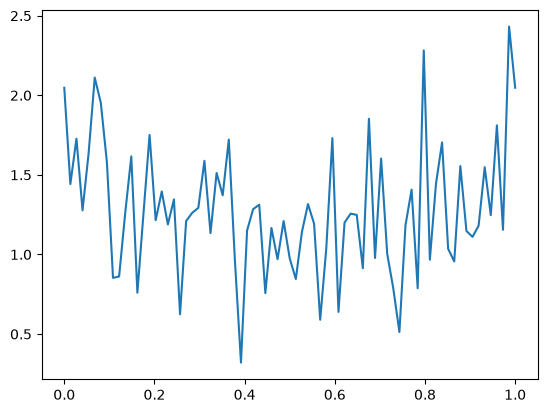

In [ ]:
'''
SEED = 42
steps = 100
max_pos = 100
symm_qrw = True
noise_type = 'X'

TIMES = 50
ALPHAS = []
P = []

for p in np.linspace(0, 1, 75):
    var_ft = []
    t = []
    #data, X = noisy_meas_circle_quantum_random_walk_1D(max_pos, steps, 0.5, symm_qrw, 0, SEED)
    
    data, X = noisy_circle_quantum_random_walk_1D(max_pos, steps, 0.5, symm_qrw, noise_type, p, None)
    np.random.seed(42)
    
    for i in range(20, 100, 10):
        t.append(i + 1)
        Y = data[i]
        var_ft.append(var_mu0(X,Y))

    log_t = np.log(t)
    log_var_ft = np.log(var_ft)
    alpha, log_C = np.polyfit(log_t, log_var_ft, 1)
    print(f'p noise: {p}, alpha: {alpha}')

    ALPHAS.append(alpha)
    P.append(p)

with open(f"./data/diffusion_alpha/{noise_type}.csv", "w") as csvfile:
        csvwriter = csv.writer(csvfile)
        csvwriter.writerow(P)
        csvwriter.writerow(ALPHAS)

plt.plot(P, ALPHAS)
'''

p noise: 0.000, alpha: 2.0657
p noise: 0.020, alpha: 1.8326
p noise: 0.040, alpha: 1.5949
p noise: 0.060, alpha: 1.5401
p noise: 0.080, alpha: 1.4101
p noise: 0.100, alpha: 1.2029
p noise: 0.120, alpha: 1.2297
p noise: 0.140, alpha: 1.2392
p noise: 0.160, alpha: 1.2950
p noise: 0.180, alpha: 1.2723
p noise: 0.200, alpha: 1.0692
p noise: 0.220, alpha: 1.1186
p noise: 0.240, alpha: 1.1618
p noise: 0.270, alpha: 1.1055
p noise: 0.290, alpha: 1.0135
p noise: 0.310, alpha: 1.0134
p noise: 0.330, alpha: 1.0551
p noise: 0.350, alpha: 1.0360
p noise: 0.370, alpha: 0.8813
p noise: 0.390, alpha: 1.1267
p noise: 0.410, alpha: 1.0724
p noise: 0.430, alpha: 1.0737
p noise: 0.450, alpha: 0.9830
p noise: 0.470, alpha: 1.0054
p noise: 0.490, alpha: 1.0419
p noise: 0.510, alpha: 1.0036
p noise: 0.530, alpha: 1.0522
p noise: 0.550, alpha: 1.0813
p noise: 0.570, alpha: 1.0441
p noise: 0.590, alpha: 1.0421
p noise: 0.610, alpha: 1.0750
p noise: 0.630, alpha: 1.0688
p noise: 0.650, alpha: 1.0876
p noise: 0

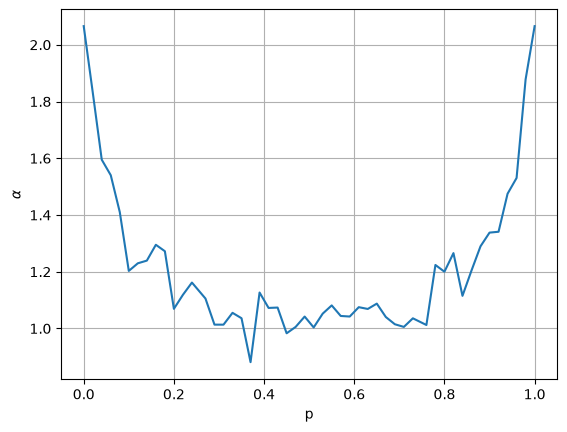

In [ ]:
SEED = 42
steps = 100
max_pos = 100
symm_qrw = True
noise_type = 'X'

TIMES = 40

ALPHAS = []
P = []


np.random.seed(SEED)

for p in np.linspace(0, 1, 50):

    p = round(p, 2)
    var_ft = []
    t = []
    sum_data = None

    for _ in range(TIMES):
        data, X = noisy_circle_quantum_random_walk_1D(
            max_pos,
            steps,
            0.5,
            symm_qrw,
            noise_type,
            p,
            None
        )

        data = np.asarray(data, dtype=float)

        if sum_data is None:
            sum_data = np.zeros_like(data)

        sum_data += data

    sum_data /= sum_data.sum(axis=1, keepdims=True)

    for i in range(10, 100, 10):

        t.append(i + 1)

        Y = sum_data[i]

        var_ft.append(var_mu0(X, Y))


    log_t = np.log(t)
    log_var_ft = np.log(var_ft)

    alpha, log_C = np.polyfit(
        log_t,
        log_var_ft,
        1
    )

    print(f'p noise: {p:.3f}, alpha: {alpha:.4f}')

    ALPHAS.append(alpha)
    P.append(p)


with open(f"./data/diffusion_alpha/{noise_type}.csv", "w", newline="") as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(P)
    csvwriter.writerow(ALPHAS)


plt.plot(P, ALPHAS)
plt.xlabel("p")
plt.ylabel(r"$\alpha$")
plt.grid()
plt.show()

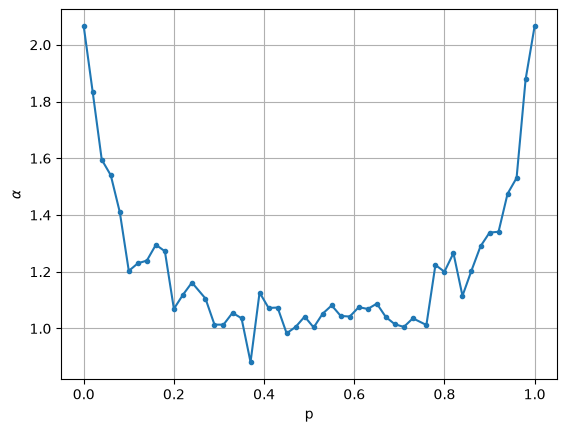

In [ ]:
SEED = 42
steps = 100
max_pos = 100
symm_qrw = True
noise_type = 'Z'

TIMES = 40

ALPHAS = []
P = []


np.random.seed(SEED)

for p in np.linspace(0, 1, 50):

    p = round(p, 2)
    var_ft = []
    t = []
    sum_data = None

    for _ in range(TIMES):
        data, X = noisy_circle_quantum_random_walk_1D(
            max_pos,
            steps,
            0.5,
            symm_qrw,
            noise_type,
            p,
            None
        )

        data = np.asarray(data, dtype=float)

        if sum_data is None:
            sum_data = np.zeros_like(data)

        sum_data += data

    sum_data /= sum_data.sum(axis=1, keepdims=True)

    for i in range(10, 100, 10):

        t.append(i + 1)

        Y = sum_data[i]

        var_ft.append(var_mu0(X, Y))


    log_t = np.log(t)
    log_var_ft = np.log(var_ft)

    alpha, log_C = np.polyfit(
        log_t,
        log_var_ft,
        1
    )

    print(f'p noise: {p:.3f}, alpha: {alpha:.4f}')

    ALPHAS.append(alpha)
    P.append(p)


with open(f"./data/diffusion_alpha/{noise_type}.csv", "w", newline="") as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(P)
    csvwriter.writerow(ALPHAS)


plt.plot(P, ALPHAS)
plt.xlabel("p")
plt.ylabel(r"$\alpha$")
plt.grid()
plt.show()

In [ ]:
SEED = 42
steps = 100
max_pos = 100
symm_qrw = True
noise_type = 'H'

TIMES = 40

ALPHAS = []
P = []


np.random.seed(SEED)

for p in np.linspace(0, 1, 50):

    p = round(p, 2)
    var_ft = []
    t = []
    sum_data = None

    for _ in range(TIMES):
        data, X = noisy_circle_quantum_random_walk_1D(
            max_pos,
            steps,
            0.5,
            symm_qrw,
            noise_type,
            p,
            None
        )

        data = np.asarray(data, dtype=float)

        if sum_data is None:
            sum_data = np.zeros_like(data)

        sum_data += data

    sum_data /= sum_data.sum(axis=1, keepdims=True)

    for i in range(10, 100, 10):

        t.append(i + 1)

        Y = sum_data[i]

        var_ft.append(var_mu0(X, Y))


    log_t = np.log(t)
    log_var_ft = np.log(var_ft)

    alpha, log_C = np.polyfit(
        log_t,
        log_var_ft,
        1
    )

    print(f'p noise: {p:.3f}, alpha: {alpha:.4f}')

    ALPHAS.append(alpha)
    P.append(p)


with open(f"./data/diffusion_alpha/{noise_type}.csv", "w", newline="") as csvfile:
    csvwriter = csv.writer(csvfile)
    csvwriter.writerow(P)
    csvwriter.writerow(ALPHAS)


plt.plot(P, ALPHAS)
plt.xlabel("p")
plt.ylabel(r"$\alpha$")
plt.grid()
plt.show()